** Take an audio recording, extract numerical characteristics from the sound, and use a machine learning model to classify what type of sound it is.

* Row - One row represents One audio file.
* A column - represents one piece of information about every audio file.

* MFCC_1 to MFCC_20 - These are your 20 MFCC features. MFCC = Mel-Frequency Cepstral Coefficients. They represent important characteristics/patterns of the audio in numerical form.(Overall spectral/timbral characteristics).

* spectral_centroid - This represents the center of the frequency distribution of the sound. Lower spectral centroid → more low-frequency energy, Higher spectral centroid → more high-frequency energy.(Where the frequency energy is concentrated).

* zcr = Zero Crossing Rate - It measures how frequently the audio waveform crosses the zero level. More crossings → often noisier higher-frequency characteristics, Fewer crossings → often smoother/lower-frequency characteristics.(How often the signal crosses zero; useful for noisiness/sharpness).

* rms = Root Mean Square. It represents the approximate energy/strength of the audio signal.(Energy/strength of the sound).

* More audio features could be extracted, but since this is a Machine Learning model, more features do not automatically mean a better model. Too many unnecessary or redundant features can add noise, increase complexity, and may not improve prediction performance. Therefore, i selected a set of relevant audio features such as MFCCs, spectral centroid, ZCR, and RMS

* target = label, It contains: Animal, Car_Sound, Gunshot, Natural_Sound, Timber_Cutting

* Prepare the extracted audio-feature dataset for machine learning.
* The original audio files have already been converted into numerical features such as:
* - 20 MFCC features
* - Spectral Centroid
* - Zero Crossing Rate (ZCR)
* - RMS Energy



# Importing Libraries

In [39]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn. metrics import precision_score, recall_score, f1_score
import librosa
import joblib

In [2]:
data = pd.read_csv(r'C:\Users\POOJA\Downloads\Bioacoustic_Threat_Detection.csv')
data

,file_name,label,spectral_centroid,zcr,rms,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,...,MFCC_11,MFCC_12,MFCC_13,MFCC_14,MFCC_15,MFCC_16,MFCC_17,MFCC_18,MFCC_19,MFCC_20
0,1766-0-0.wav,Animal,3195.685641,0.101495,0.043030,-390.90213,26.158420,-33.765990,9.771124,17.299381,...,-7.346553,9.220031,7.037331,5.381076,-3.229103,14.574335,5.864018,1.042480,1.459060,7.603073
1,1766-1-0.wav,Animal,1349.122155,0.060642,0.119726,-164.20299,146.183090,-7.350566,18.943148,-12.121687,...,-1.502207,1.371719,3.012767,3.657836,-0.162359,0.648856,-0.884865,1.373793,-3.387695,-2.527411
2,1766-10-0.wav,Animal,1017.375205,0.049974,0.077167,-333.23200,160.450360,15.704328,-4.308052,-8.489619,...,-3.383368,0.947493,-5.707964,-1.920007,-1.499015,-2.806960,2.318773,3.066898,0.946940,-5.829171
3,1766-100-0.wav,Animal,504.597234,0.021161,0.036359,-469.01263,13.840074,-4.567105,0.439847,7.558582,...,6.946756,6.495979,2.100464,-2.175540,-3.145462,-2.058385,1.990385,0.118798,-2.719790,-0.392674
4,1766-101-0.wav,Animal,2043.137666,0.125212,0.021946,-263.17422,93.858185,-62.927498,-41.319990,-28.224531,...,-19.606949,-19.701283,-21.951305,-12.044013,-9.357104,-8.736371,-13.395556,-5.572871,-3.513938,0.948869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2253,7_10771.wav,Timber_Cutting,2888.451060,0.174314,0.105405,-70.20287,77.860390,-18.401003,-5.047463,-1.263211,...,-15.453920,10.188420,-1.686451,1.439444,-6.394534,3.000406,-4.368853,-3.162574,3.258628,-2.714844
2254,7_10772.wav,Timber_Cutting,2926.413717,0.158474,0.006340,-372.09183,74.083710,-14.326224,8.796776,-12.909889,...,-0.448168,-4.361135,-8.225810,-3.857949,-8.964672,-1.428786,-7.251109,-1.041942,-2.429767,4.750042
2255,7_10773.wav,Timber_Cutting,2626.396769,0.158334,0.051955,-136.55025,90.550710,-17.941952,-3.036111,-10.696438,...,-3.812421,0.688562,-5.119955,1.263780,-2.131340,0.939998,-3.224611,0.189141,-6.906513,-2.511311
2256,7_10774.wav,Timber_Cutting,2589.404953,0.135679,0.034749,-271.56677,90.130035,-18.111921,-1.951030,0.508182,...,-4.747082,-1.022623,8.638170,-5.682916,-0.301943,11.861046,-6.633414,8.329766,-5.961752,5.868329


# Data Preprocessing

In [3]:
print(data.head())

        file_name   label  spectral_centroid       zcr       rms     MFCC_1  \
0    1766-0-0.wav  Animal        3195.685641  0.101495  0.043030 -390.90213   
1    1766-1-0.wav  Animal        1349.122155  0.060642  0.119726 -164.20299   
2   1766-10-0.wav  Animal        1017.375205  0.049974  0.077167 -333.23200   
3  1766-100-0.wav  Animal         504.597234  0.021161  0.036359 -469.01263   
4  1766-101-0.wav  Animal        2043.137666  0.125212  0.021946 -263.17422   

       MFCC_2     MFCC_3     MFCC_4     MFCC_5  ...    MFCC_11    MFCC_12  \
0   26.158420 -33.765990   9.771124  17.299381  ...  -7.346553   9.220031   
1  146.183090  -7.350566  18.943148 -12.121687  ...  -1.502207   1.371719   
2  160.450360  15.704328  -4.308052  -8.489619  ...  -3.383368   0.947493   
3   13.840074  -4.567105   0.439847   7.558582  ...   6.946756   6.495979   
4   93.858185 -62.927498 -41.319990 -28.224531  ... -19.606949 -19.701283   

     MFCC_13    MFCC_14   MFCC_15    MFCC_16    MFCC_17   MFCC

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2258 entries, 0 to 2257
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   file_name          2258 non-null   object 
 1   label              2258 non-null   object 
 2   spectral_centroid  2258 non-null   float64
 3   zcr                2258 non-null   float64
 4   rms                2258 non-null   float64
 5   MFCC_1             2258 non-null   float64
 6   MFCC_2             2258 non-null   float64
 7   MFCC_3             2258 non-null   float64
 8   MFCC_4             2258 non-null   float64
 9   MFCC_5             2258 non-null   float64
 10  MFCC_6             2258 non-null   float64
 11  MFCC_7             2258 non-null   float64
 12  MFCC_8             2258 non-null   float64
 13  MFCC_9             2258 non-null   float64
 14  MFCC_10            2258 non-null   float64
 15  MFCC_11            2258 non-null   float64
 16  MFCC_12            2258 

In [5]:
print(data.describe())

       spectral_centroid          zcr          rms       MFCC_1       MFCC_2  \
count        2258.000000  2258.000000  2258.000000  2258.000000  2258.000000   
mean         2267.567718     0.123388     0.074992  -279.272357    89.831730   
std          1207.468705     0.108791     0.083331   166.458039    52.919284   
min           161.061537     0.001681     0.000381  -773.099730  -152.223370   
25%          1398.753204     0.051076     0.017767  -389.688245    53.128937   
50%          2056.372247     0.092081     0.048835  -279.004975    87.098395   
75%          2923.801968     0.162370     0.100008  -152.391343   126.596482   
max          9770.509020     0.902816     0.779576    62.348114   226.734880   

            MFCC_3       MFCC_4       MFCC_5       MFCC_6       MFCC_7  ...  \
count  2258.000000  2258.000000  2258.000000  2258.000000  2258.000000  ...   
mean    -10.871021    12.100450    -3.443144     6.648545    -1.545521  ...   
std      32.964226    20.193511    16.4109

In [6]:
print(data.isnull().sum())

file_name            0
label                0
spectral_centroid    0
zcr                  0
rms                  0
MFCC_1               0
MFCC_2               0
MFCC_3               0
MFCC_4               0
MFCC_5               0
MFCC_6               0
MFCC_7               0
MFCC_8               0
MFCC_9               0
MFCC_10              0
MFCC_11              0
MFCC_12              0
MFCC_13              0
MFCC_14              0
MFCC_15              0
MFCC_16              0
MFCC_17              0
MFCC_18              0
MFCC_19              0
MFCC_20              0
dtype: int64


In [7]:
print(data.duplicated().sum())

0


There is no duplicte and missing value in the data set

In [8]:
print(data['label'].value_counts())

label
Animal            460
Natural_Sound     454
Car_Sound         450
Gunshot           449
Timber_Cutting    445
Name: count, dtype: int64


In [9]:
# removing non - important column
data.drop('file_name', axis =1, inplace = True)

# Visulaizations

* Class distribution in label(5 classess)

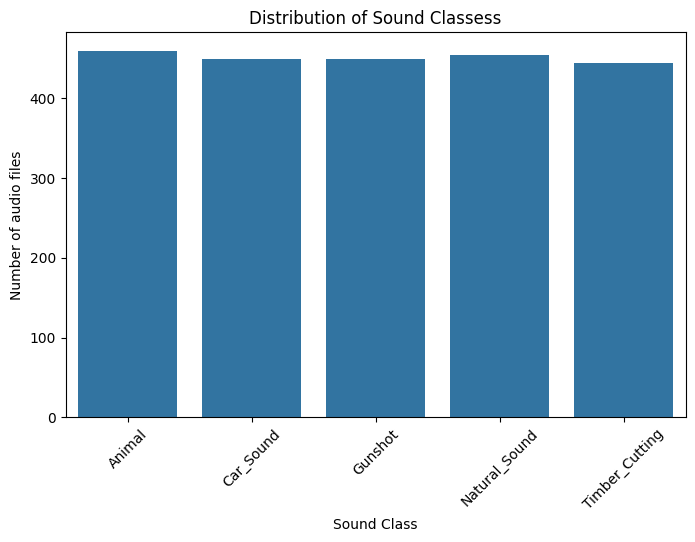

In [10]:
plt.figure(figsize = (8,5))
sns.countplot(data = data, x = 'label')
plt.title('Distribution of Sound Classess')
plt.xlabel('Sound Class')
plt.ylabel('Number of audio files')
plt.xticks(rotation = 45)
plt.show()

The dataset contains 5 classess: Animal, Car_Sound, Gunshot, Natural_Sound, Timber_Cutting. Each class contains ~ 445 - 460 audio samples, indicating that the dataset is relatively balance. Therefore, no class has a major representation over the others.

* Spectral Centroid by sound class

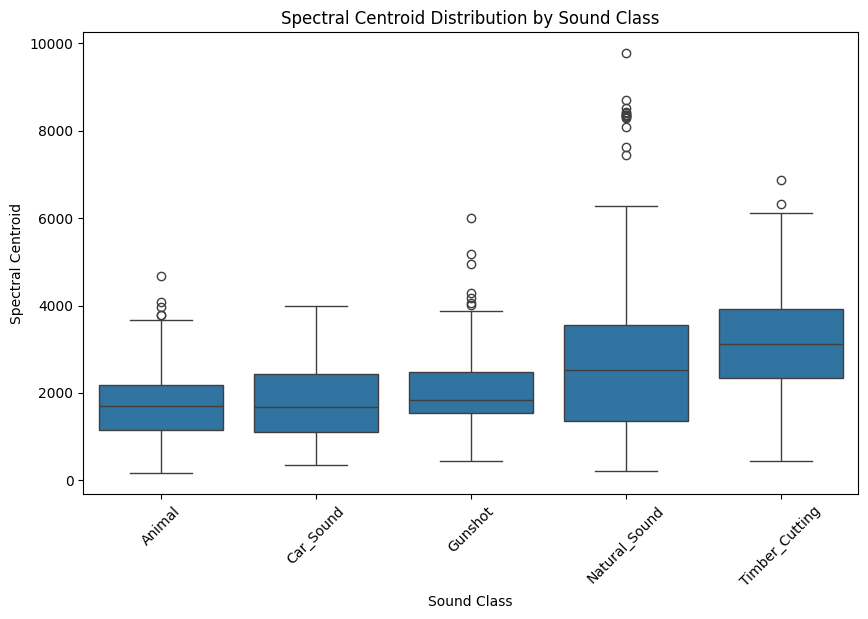

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data = data, x = 'label', y ='spectral_centroid')
plt.title('Spectral Centroid Distribution by Sound Class')
plt.xlabel('Sound Class')
plt.ylabel('Spectral Centroid')
plt.xticks(rotation = 45)
plt.show()

Spectral Centroid Analysis: The distributions of Spectral centroid varies across five classess. Timber_Cutting(have highest median spectral distribution) and Natural_Sound(higher median several high outlier) generally show higher spectral centroid values, while Animal(lower to middle range, higher outliers) and Car_Sound(generally around similar to animal) tend to have lower values. Gunshot(Generally higher than Animal and Car_Sound, with some high-frequency outliers).

* Assigning x and y

In [12]:
# seperate x and y
x = data.drop('label', axis = 1)
y = data['label']

In [13]:
print('x Shape:',x.shape)
print('y shape', y.shape)

x Shape: (2258, 23)
y shape (2258,)


* Encoding Categorical Column

In [14]:
# target column is object, converting it
le = LabelEncoder()
y_encoded = le.fit_transform(y)

* Splitting the data

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size = 0.2, random_state = 42, stratify= y_encoded)

In [16]:
print('x train:', x_train.shape)
print('x test:', x_test.shape)
print('y train:', y_train.shape)
print('y test:', y_test.shape)

x train: (1806, 23)
x test: (452, 23)
y train: (1806,)
y test: (452,)


* Scaling numerical column

In [17]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [18]:
print('x train scaled:', x_train_scaled.shape)
print('x test scaled:', x_test_scaled.shape)

x train scaled: (1806, 23)
x test scaled: (452, 23)


# Creating the models

# 1. Logistic regression

In [19]:
logistic_model = LogisticRegression(max_iter = 1000)
logistic_model.fit(x_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [20]:
logistic_pred = logistic_model.predict(x_test_scaled)

In [21]:
print('Logistic Regression Model Accuracy is:', accuracy_score(y_test, logistic_pred))

Logistic Regression Model Accuracy is: 0.5553097345132744


In [22]:
print('\nClassification report:\n', classification_report(y_test, logistic_pred))
print('confusion matrix:\n', confusion_matrix(y_test, logistic_pred))


Classification report:
               precision    recall  f1-score   support

           0       0.51      0.48      0.49        92
           1       0.65      0.81      0.72        90
           2       0.62      0.59      0.61        90
           3       0.44      0.31      0.36        91
           4       0.51      0.60      0.55        89

    accuracy                           0.56       452
   macro avg       0.55      0.56      0.55       452
weighted avg       0.55      0.56      0.55       452

confusion matrix:
 [[44 17 11  9 11]
 [ 5 73  4  6  2]
 [18  2 53  5 12]
 [13 16  9 28 25]
 [ 7  5  8 16 53]]


# 2. SVM

In [23]:
svm_model = SVC()
svm_model.fit(x_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [24]:
svm_pred = svm_model.predict(x_test_scaled)

In [25]:
print('SVM Model Accuracy is:', accuracy_score(y_test, svm_pred))

SVM Model Accuracy is: 0.7853982300884956


In [26]:
print('Classification report:\n', classification_report(y_test, svm_pred))
print('confusion matrix:\n', confusion_matrix(y_test, svm_pred))

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77        92
           1       0.80      0.93      0.86        90
           2       0.87      0.79      0.83        90
           3       0.84      0.65      0.73        91
           4       0.68      0.79      0.73        89

    accuracy                           0.79       452
   macro avg       0.79      0.79      0.78       452
weighted avg       0.79      0.79      0.78       452

confusion matrix:
 [[71  7  7  2  5]
 [ 3 84  1  1  1]
 [ 6  0 71  2 11]
 [ 5 10  1 59 16]
 [ 7  4  2  6 70]]


# 3. Random forest

In [27]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [28]:
rf_pred = rf_model.predict(x_test)

In [29]:
print('Random forest Model Accuracy is:', accuracy_score(y_test, rf_pred))

Random forest Model Accuracy is: 0.7920353982300885


In [30]:
print('Classification report:\n', classification_report(y_test, rf_pred))
print('confusion matrix:\n', confusion_matrix(y_test, rf_pred))

Classification report:
               precision    recall  f1-score   support

           0       0.74      0.82      0.77        92
           1       0.83      0.94      0.88        90
           2       0.84      0.72      0.78        90
           3       0.81      0.65      0.72        91
           4       0.76      0.83      0.80        89

    accuracy                           0.79       452
   macro avg       0.80      0.79      0.79       452
weighted avg       0.79      0.79      0.79       452

confusion matrix:
 [[75  5  4  6  2]
 [ 2 85  1  2  0]
 [11  1 65  3 10]
 [ 9  8  4 59 11]
 [ 5  4  3  3 74]]


# Comparing all three Models

In [31]:
comparison = pd.DataFrame({'Model':['Logistic Regression', 'SVM', 'Random Forest'], 'Accuracy': [accuracy_score(y_test, logistic_pred), accuracy_score(y_test, svm_pred),accuracy_score(y_test, rf_pred)], 'Precission': [precision_score(y_test, logistic_pred, average = 'weighted'), precision_score(y_test, svm_pred, average = 'weighted'), precision_score(y_test, rf_pred, average = 'weighted')],'Recall': [recall_score(y_test, logistic_pred, average = 'weighted'), recall_score(y_test, svm_pred, average = 'weighted'), recall_score(y_test, rf_pred, average = 'weighted')], 'F1 score': [f1_score(y_test, logistic_pred, average = 'weighted'), f1_score(y_test, svm_pred, average = 'weighted'), f1_score(y_test, rf_pred, average = 'weighted')]})
# weighted - is given because it is a 5 - class classification problem - It calculates the metric for each class and then gives each class importance according to how many samples that class has.
print(comparison)

                 Model  Accuracy  Precission    Recall  F1 score
0  Logistic Regression  0.555310    0.545125  0.555310  0.545321
1                  SVM  0.785398    0.792284  0.785398  0.784142
2        Random Forest  0.792035    0.794995  0.792035  0.789295


* Random Forest is currently the best model, out of the three with accuracy 0.79

Tuning the Random Forest Model to improve accuracy

In [32]:
# tuning to improve the accuracy for random forest
rf_model1 = RandomForestClassifier(n_estimators = 300, max_depth = None, min_samples_split = 2, min_samples_leaf = 1, random_state = 42)
rf_model1.fit(x_train, y_train)
rf_model1_pred = rf_model1.predict(x_test)
print('rf_model1 accuracy:', accuracy_score(y_test, rf_model1_pred))
print('Precision Score:', precision_score(y_test, rf_model1_pred,average = 'weighted'))
print('Recall Score:', recall_score(y_test, rf_model1_pred,average = 'weighted'))
print('F1 Score:', f1_score(y_test, rf_model1_pred,average = 'weighted'))

rf_model1 accuracy: 0.8097345132743363
Precision Score: 0.8141401873011386
Recall Score: 0.8097345132743363
F1 Score: 0.8081811176507577


In [33]:
print('Classification Report of Tuned Random Forest Model:\n', classification_report(y_test, rf_model1_pred))
print('Confusion matrix of tuned random Forest Model:\n', confusion_matrix(y_test, rf_model1_pred))

Classification Report of Tuned Random Forest Model:
               precision    recall  f1-score   support

           0       0.73      0.84      0.78        92
           1       0.86      0.94      0.90        90
           2       0.88      0.72      0.79        90
           3       0.82      0.70      0.76        91
           4       0.78      0.84      0.81        89

    accuracy                           0.81       452
   macro avg       0.81      0.81      0.81       452
weighted avg       0.81      0.81      0.81       452

Confusion matrix of tuned random Forest Model:
 [[77  5  3  6  1]
 [ 2 85  1  2  0]
 [11  0 65  2 12]
 [ 9  7  3 64  8]
 [ 6  2  2  4 75]]


##### The random Forest accuracy went from 0.79 to 0.80 by tuning

#### Checking actual value and Predicted Value

In [34]:
comp = pd.DataFrame({'Actual': y_test, 'Predicted': rf_pred})
print(comp.head(10))

   Actual  Predicted
0       3          4
1       0          0
2       3          3
3       3          0
4       0          0
5       3          3
6       2          4
7       2          4
8       1          1
9       1          1


### Testing the prediction

In [35]:
test_file = r'C:\Users\POOJA\Downloads\FSM5\Natural_Sound\1766-0-1.wav'
y_new, sr_new = librosa.load(test_file, sr = 22050, mono = True) # sr = how many samples are taken/used per second of audio.
# Some audio files are stereo, meaning they have two channels: Stereo audio, --> Left channel  +  Right channel.
# when, mono=True is used - Librosa combines them into one single audio channel:

# extracting features from audio

mfcc_new = librosa.feature.mfcc(y  = y_new, sr = sr_new, n_mfcc = 20)
# mfcc - Mel-Frequency Capstral Coefficients. , n_mfcc - number of MFCC Coefficients.

mfcc_new_mean = np.mean(mfcc_new, axis = 1)

spectral_cen_new = librosa.feature.spectral_centroid(y = y_new, sr = sr_new)
spectral_mean_new =np.mean(spectral_cen_new) 

zcr_new = librosa.feature.zero_crossing_rate(y = y_new)
zcr_mean_new = np.mean(zcr_new)

rms_new = librosa.feature.rms(y = y_new)
rms_mean_new = np.mean(rms_new)

In [36]:
# adding the extracted features into a row
new_features = np.concatenate([[spectral_mean_new], [zcr_mean_new],[rms_mean_new],mfcc_new_mean]) # mfcc already lookes lik mfcc_mean_new =[-390, 26, -33, 9, ..., 7]
# so we do not need brackets there, but the rest of the values are like Eg: 3000(single values), so bracket is needed there.
print('Number of Faetures:', len(new_features))

Number of Faetures: 23


In [37]:
new_features = new_features.reshape(1,-1)
print('New Features Shape:', new_features.shape)

New Features Shape: (1, 23)


In [38]:
prediction = rf_model1.predict(new_features)
predicted_label = le.inverse_transform(prediction)
print('Predicted Sound:', predicted_label[0])

Predicted Sound: Natural_Sound


c:\Users\POOJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
joblib.dump(rf_model, 'rf_model1.pkl') # sice we need this data, we are storing it in .pkl format
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']